In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
from google.colab import files
uploaded = files.upload()

Saving fake_job_postings.csv to fake_job_postings.csv


In [3]:
df = pd.read_csv('fake_job_postings.csv')
data = df.copy()
print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
data.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [5]:
data.shape

(17880, 18)

In [6]:
data.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [8]:
data.isnull().sum().sort_values(ascending=False)

,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


In [9]:
data['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


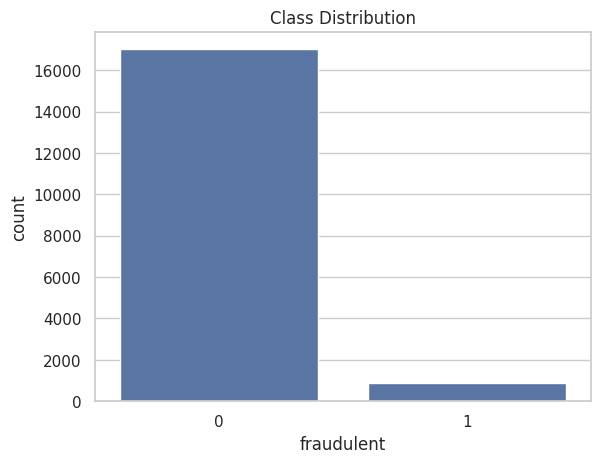

In [10]:
sns.countplot(x='fraudulent', data=data)
plt.title("Class Distribution")
plt.show()

In [11]:
# Check missing values again
data.isnull().sum().sort_values(ascending=False)

,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


In [12]:
text_columns = [
    'title',
    'location',
    'company_profile',
    'description',
    'requirements',
    'benefits'
]

for col in text_columns:
    data[col] = data[col].fillna('')

print("Missing text values handled")

Missing text values handled


In [13]:
data['combined_text'] = (
    data['title'] + " " +
    data['company_profile'] + " " +
    data['description'] + " " +
    data['requirements'] + " " +
    data['benefits']
)

data['combined_text'].head()

,combined_text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


In [14]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [15]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [16]:
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [17]:
data['cleaned_text'] = data['combined_text'].apply(clean_text)

data[['combined_text', 'cleaned_text']].head()

,combined_text,cleaned_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food created groundbreaking a...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc g...


In [18]:
print(data['cleaned_text'][0])

marketing intern food created groundbreaking award winning cooking site support connect celebrate home cooks give everything need one place top editorial business engineering team focused using technology find new better ways connect people around specific food interests offer superb highly curated information food cooking attract talented home cooks contributors country also publish well known professionals like mario batali gwyneth paltrow danny meyer partnerships whole foods market random house food named best food website james beard foundation iacp featured new york times npr pando daily techcrunch today show located chelsea new york city food fast growing james beard award winning online food community crowd sourced curated recipe hub currently interviewing full part time unpaid interns work small team editors executives developers new york city headquarters reproducing repackaging existing food content number partner sites huffington post yahoo buzzfeed various content managemen

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


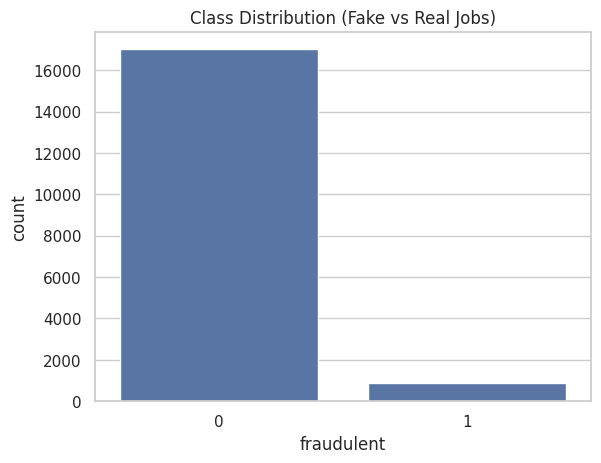

In [19]:
# Percentage distribution
fraud_counts = data['fraudulent'].value_counts(normalize=True) * 100
print(fraud_counts)

# Visualization
sns.countplot(x='fraudulent', data=data)
plt.title("Class Distribution (Fake vs Real Jobs)")
plt.show()

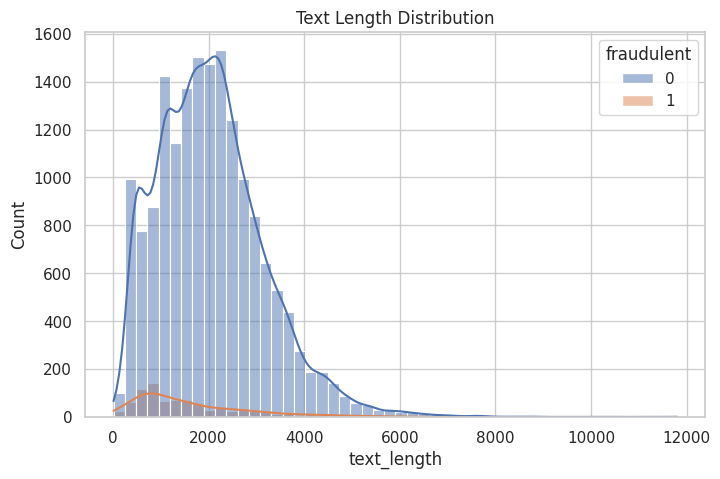

In [20]:
data['text_length'] = data['cleaned_text'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=data, x='text_length', hue='fraudulent', bins=50, kde=True)
plt.title("Text Length Distribution")
plt.show()

In [21]:
from collections import Counter

# Split words
all_words = " ".join(data['cleaned_text']).split()

word_freq = Counter(all_words)

# Top 20 words
common_words = word_freq.most_common(20)
print(common_words)

[('experience', 39751), ('work', 37323), ('team', 34135), ('e', 24232), ('b', 23066), ('company', 22398), ('business', 22257), ('f', 22095), ('c', 21948), ('skills', 19690), ('new', 18000), ('customer', 17996), ('management', 16966), ('amp', 16613), ('sales', 16486), ('development', 16264), ('working', 15964), ('services', 15736), ('time', 15653), ('service', 14655)]


In [22]:
fake_jobs = data[data['fraudulent'] == 1]
real_jobs = data[data['fraudulent'] == 0]

In [23]:
def get_top_words(text_series):
    words = " ".join(text_series).split()
    return Counter(words).most_common(20)

In [24]:
fake_words = get_top_words(fake_jobs['cleaned_text'])
real_words = get_top_words(real_jobs['cleaned_text'])

print("Fake Job Words:\n", fake_words)
print("\nReal Job Words:\n", real_words)

Fake Job Words:
 [('work', 1775), ('experience', 1610), ('e', 1364), ('c', 1347), ('b', 1224), ('skills', 1178), ('amp', 1154), ('f', 1129), ('team', 856), ('company', 856), ('time', 823), ('service', 735), ('management', 733), ('business', 721), ('customer', 710), ('position', 681), ('ability', 653), ('data', 651), ('engineering', 635), ('project', 606)]

Real Job Words:
 [('experience', 38141), ('work', 35548), ('team', 33279), ('e', 22868), ('b', 21842), ('company', 21542), ('business', 21536), ('f', 20966), ('c', 20601), ('skills', 18512), ('new', 17448), ('customer', 17286), ('management', 16233), ('sales', 16063), ('development', 15777), ('working', 15483), ('amp', 15459), ('services', 15154), ('time', 14830), ('service', 13920)]


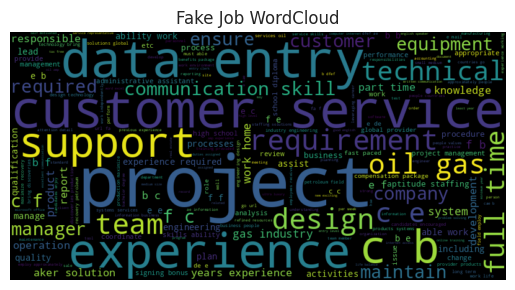

In [25]:
from wordcloud import WordCloud

# Fake jobs wordcloud
fake_text = " ".join(fake_jobs['cleaned_text'])

wordcloud = WordCloud(width=800, height=400).generate(fake_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Fake Job WordCloud")
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

X = data['cleaned_text']
y = data['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (14304,)
Test size: (3576,)


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [28]:
tfidf = TfidfVectorizer(
    max_features=5000,   # limit vocabulary size
    ngram_range=(1,2),   # unigrams + bigrams
    min_df=5,            # ignore rare words
    max_df=0.8           # ignore overly common words
)

In [29]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (14304, 5000)


In [30]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:20])

['aa' 'aabbf' 'aabbf ca' 'ab' 'ab da' 'ab ea' 'abc' 'abc supply'
 'abilities' 'ability' 'ability adapt' 'ability build'
 'ability communicate' 'ability effectively' 'ability learn'
 'ability manage' 'ability multi' 'ability prioritize' 'ability take'
 'ability work']


In [31]:
# Sum TF-IDF scores
import numpy as np

tfidf_scores = np.sum(X_train_tfidf.toarray(), axis=0)

top_indices = np.argsort(tfidf_scores)[-20:]

top_words = [feature_names[i] for i in top_indices]

print(top_words)

['time', 'product', 'web', 'data', 'working', 'service', 'services', 'design', 'management', 'new', 'marketing', 'development', 'skills', 'amp', 'company', 'customer', 'business', 'sales', 'team', 'work']


In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)

In [34]:
lr_model.fit(X_train_tfidf, y_train)

print("Model trained successfully")

Model trained successfully


In [35]:
y_pred = lr_model.predict(X_test_tfidf)
y_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9725950782997763
Precision: 0.6595744680851063
Recall: 0.8959537572254336
F1 Score: 0.7598039215686274


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3403
           1       0.66      0.90      0.76       173

    accuracy                           0.97      3576
   macro avg       0.83      0.94      0.87      3576
weighted avg       0.98      0.97      0.97      3576



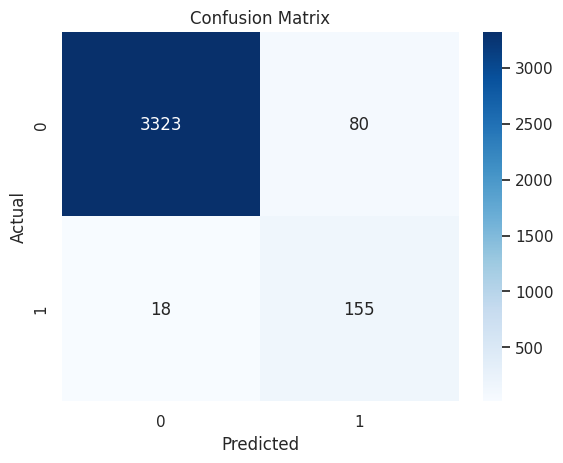

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
feature_names = tfidf.get_feature_names_out()
coefficients = lr_model.coef_[0]

top_positive = np.argsort(coefficients)[-20:]
top_negative = np.argsort(coefficients)[:20]

print("Top Fraud Indicators:")
print([feature_names[i] for i in top_positive])

print("\nTop Legitimate Indicators:")
print([feature_names[i] for i in top_negative])

Top Fraud Indicators:
['administrative', 'per', 'hospital', 'email', 'work home', 'clerk', 'accountant', 'cash', 'financing', 'phone', 'cf', 'offshore', 'engineering', 'high school', 'oil gas', 'money', 'data entry', 'earn', 'aptitude', 'link']

Top Legitimate Indicators:
['team', 'companies', 'english', 'digital', 'recruitment', 'based', 'growing', 'clients', 'software', 'fun', 'web', 'love', 'search', 'creative', 'fast', 'marketing', 'like', 'startup', 'become', 'hardware']


In [41]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [42]:
print("Naive Bayes Results:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.88      0.42      0.57       173

    accuracy                           0.97      3576
   macro avg       0.93      0.71      0.78      3576
weighted avg       0.97      0.97      0.96      3576



In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

In [44]:
print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.56      0.72       173

    accuracy                           0.98      3576
   macro avg       0.99      0.78      0.85      3576
weighted avg       0.98      0.98      0.98      3576



In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):
    return {
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, y_pred),
    "Naive Bayes": evaluate_model(y_test, y_pred_nb),
    "Random Forest": evaluate_model(y_test, y_pred_rf)
}).T

results

,Precision,Recall,F1 Score
Logistic Regression,0.659574,0.895954,0.759804
Naive Bayes,0.879518,0.421965,0.570312
Random Forest,1.000000,0.560694,0.718519


In [46]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.984119758322731


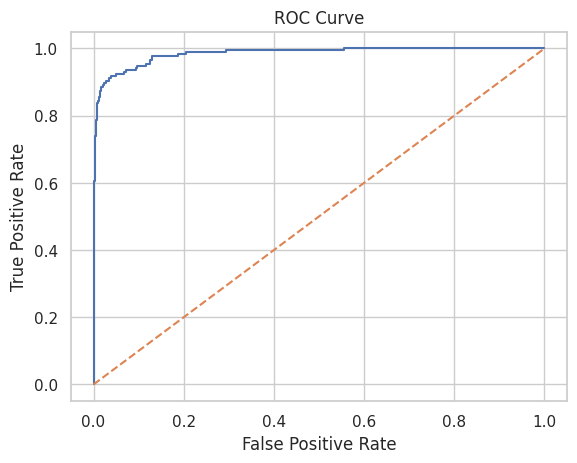

In [47]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [48]:
tfidf_improved = TfidfVectorizer(
    max_features=10000,     # increased vocabulary
    ngram_range=(1,3),      # uni + bi + tri-grams
    min_df=3,
    max_df=0.85
)

X_train_tfidf2 = tfidf_improved.fit_transform(X_train)
X_test_tfidf2 = tfidf_improved.transform(X_test)

print("Improved TF-IDF shape:", X_train_tfidf2.shape)

Improved TF-IDF shape: (14304, 10000)


In [49]:
!pip install imbalanced-learn

In [50]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf2, y_train)

print("After SMOTE:", X_train_resampled.shape)

After SMOTE: (27222, 10000)


In [52]:
lr_improved = LogisticRegression(max_iter=1000)

lr_improved.fit(X_train_resampled, y_train_resampled)

y_pred_improved = lr_improved.predict(X_test_tfidf2)
y_prob_improved = lr_improved.predict_proba(X_test_tfidf2)[:, 1]

In [53]:
print(classification_report(y_test, y_pred_improved))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.78      0.87      0.83       173

    accuracy                           0.98      3576
   macro avg       0.89      0.93      0.91      3576
weighted avg       0.98      0.98      0.98      3576



In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='f1',
    verbose=1
)

grid.fit(X_train_resampled, y_train_resampled)

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Params: {'C': 10, 'solver': 'liblinear'}


In [55]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_tfidf2)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.89      0.85      0.87       173

    accuracy                           0.99      3576
   macro avg       0.94      0.92      0.93      3576
weighted avg       0.99      0.99      0.99      3576



In [56]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_tfidf2)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.89      0.85      0.87       173

    accuracy                           0.99      3576
   macro avg       0.94      0.92      0.93      3576
weighted avg       0.99      0.99      0.99      3576



In [57]:
threshold = 0.3

y_pred_custom = (y_prob_improved >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      3403
           1       0.54      0.94      0.68       173

    accuracy                           0.96      3576
   macro avg       0.77      0.95      0.83      3576
weighted avg       0.97      0.96      0.96      3576



In [58]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save TF-IDF
with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf_improved, f)